In [1]:
%matplotlib inline
if '_LOCAL_PATH_LOADED' not in locals():
    %load_ext autoreload
    %autoreload 2
    import os
    import sys
    module_root='C:/Users/orduk/PycharmProjects/backtest'
    module_path = os.path.abspath(module_root) # or the path to your source code
    sys.path.insert(0, module_path)
    print(f'Added {module_root} to PYTHONPATH')
    _LOCAL_PATH_LOADED=True

Added C:/Users/orduk/PycharmProjects/backtest to PYTHONPATH


In [2]:
from market_data.extractalpha.datasets import EAEstimize
from datetime import date
from strategy.ensemble import filterByUniverse
from quant.symreturns import SymReturns
import numpy as np
import logging

In [3]:
logging.basicConfig(level=logging.INFO)
START_DATE,END_DATE = date(2010,1,1),date(2023,12,31)
eas = EAEstimize()

In [4]:
data = eas.retrieveSignal(START_DATE,END_DATE, additionalWhereClause = '((signal>50)|(signal<-50))')
data.rename(columns={'ticker':'sym','Date':'date'},inplace=True)
data = filterByUniverse(data,universe='IWV')
sr = SymReturns()
data = sr.enrichWithReturns(data,columns=['sym', 'volume', 'date', 'o2c', 'o2cdn', 'o2csn', 'o2cbn'])
minVolume, minPrice = 10000.0, 4.0
data = data[(data.volume > minVolume) & (data.close >= minPrice)]
data = data.replace([np.inf, -np.inf], np.nan).dropna()

INFO:root:EXECUTING 
            {[syms;sd;ed]
                (select Date, ticker, cusip, ticker_NOW, CUSIP_NOW, etype, signal, reports_at, `float$year, asof_date from eaestimize where year >= `year$sd, year <=`year$ed,Date>=sd,Date<=ed,((signal>50)|(signal<-50)))
            }
        
INFO:root:EXECUTING 
        {
        [trades]
        trades: select sym,`date$date from trades;
        .miny: exec min `year$date from trades;
        .maxy: exec max `year$date from trades;
        .temp:select sym, date, o2c, o2cdn, o2cbn, o2csn from sym_returns where year within (.miny;.maxy), sym in (exec sym from trades), date in (exec date from trades);
        .temp2: select date,sym,adjusted_close,close,`float$volume from eodhd_price where year within (.miny;.maxy),sym in (exec sym from trades), date in (exec date from trades);
        (trades lj 2!.temp) lj 2!.temp2
        }
        


In [5]:
data.columns

Index(['date', 'sym', 'cusip', 'ticker_NOW', 'CUSIP_NOW', 'etype', 'signal',
       'reports_at', 'year', 'asof_date', 'o2c', 'o2cdn', 'o2cbn', 'o2csn',
       'adjusted_close', 'close', 'volume'],
      dtype='object')

In [6]:
data['pos']=0
data.loc[data.signal>0,'pos']=1
data.loc[data.signal<0,'pos']=-1

In [7]:
data['ew_return'] = data.pos * data.o2cbn

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_dual_axis(series1, series2, series1_label='Series 1', series2_label='Series 2'):
    fig, ax1 = plt.subplots()

    color = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel(series1_label, color=color)
    ax1.plot(series1.index, series1, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel(series2_label, color=color)
    ax2.bar(series2.index, series2, color=color, alpha=0.6)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.show()

0.0005247323282467062


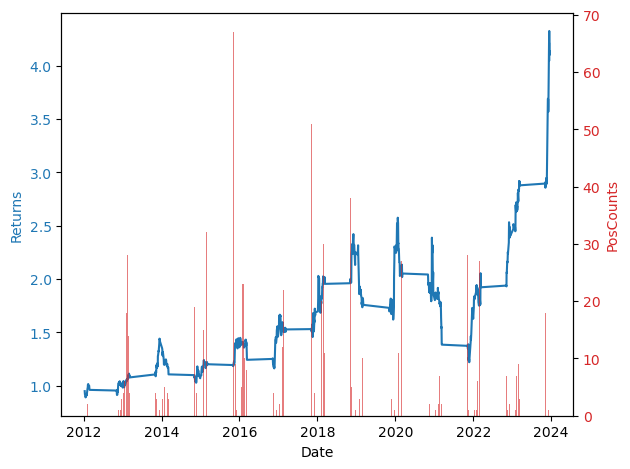

In [25]:
subset = data[data.signal.abs()>=50]
subset = data[data.etype=='post']

drets=subset.groupby(subset.date)['ew_return'].mean()
poscounts=subset.groupby(subset.date)['ew_return'].count()
print(subset['ew_return'].mean())
prets = (1+drets).cumprod()
plot_dual_axis(prets,poscounts, 'Returns', 'PosCounts')